# Image Stitching Step-by-Step

In this notebook, we will break down the image stitching process and visualize the intermediate results: keypoints, matches, warping, and blending.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Import our core library modules
from image_stitching.stitch_toy import TwoImageToyStitcher
from image_stitching.pyramid import ImagePyramid

# Initialize our stitcher
stitcher = TwoImageToyStitcher()

## 1. Load Images

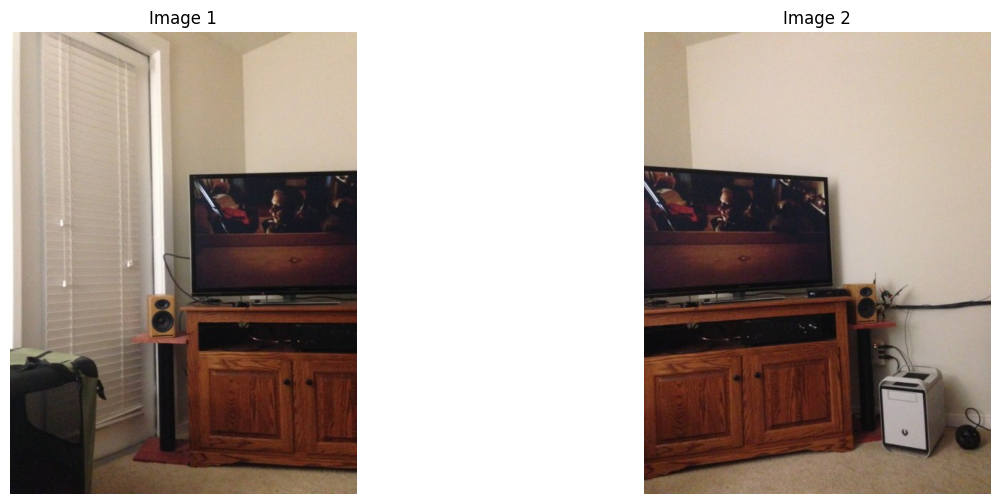

In [2]:
img1_path = '../imgs/1.jpg'
img2_path = '../imgs/2.jpg'

image1, image2, image1Gray, image2Gray = stitcher._read(img1_path, img2_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
ax1.set_title("Image 1")
ax1.axis('off')
ax2.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
ax2.set_title("Image 2")
ax2.axis('off')
plt.show()

## 2. Keypoint Detection
We use SIFT to detect keypoints and compute descriptors.

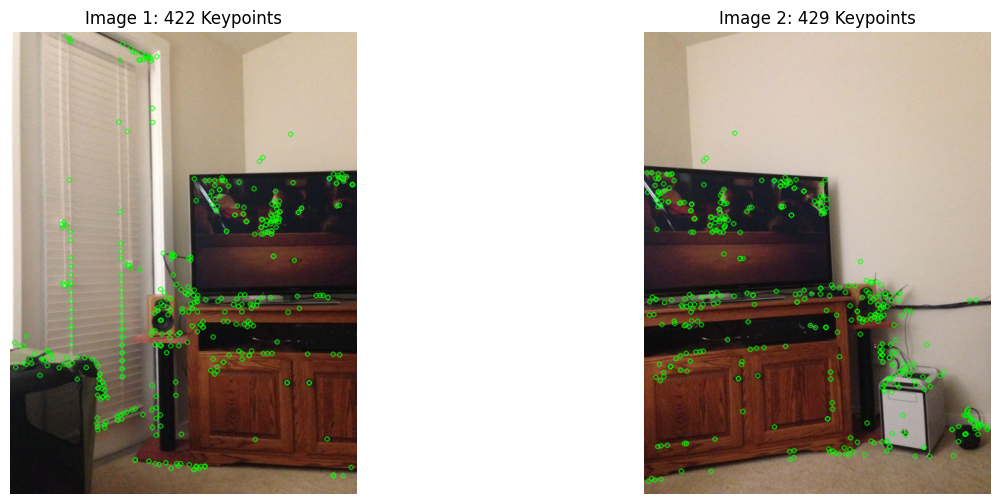

In [3]:
pts1, des1, pts2, des2 = stitcher._computeDescription(image1Gray, image2Gray)

img1_kp = cv2.drawKeypoints(image1, pts1, None, color=(0,255,0), flags=0)
img2_kp = cv2.drawKeypoints(image2, pts2, None, color=(0,255,0), flags=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.imshow(cv2.cvtColor(img1_kp, cv2.COLOR_BGR2RGB))
ax1.set_title(f"Image 1: {len(pts1)} Keypoints")
ax1.axis('off')
ax2.imshow(cv2.cvtColor(img2_kp, cv2.COLOR_BGR2RGB))
ax2.set_title(f"Image 2: {len(pts2)} Keypoints")
ax2.axis('off')
plt.show()

## 3. Feature Matching
We match descriptors using K-Nearest Neighbors and apply Lowe's ratio test to filter out bad matches.

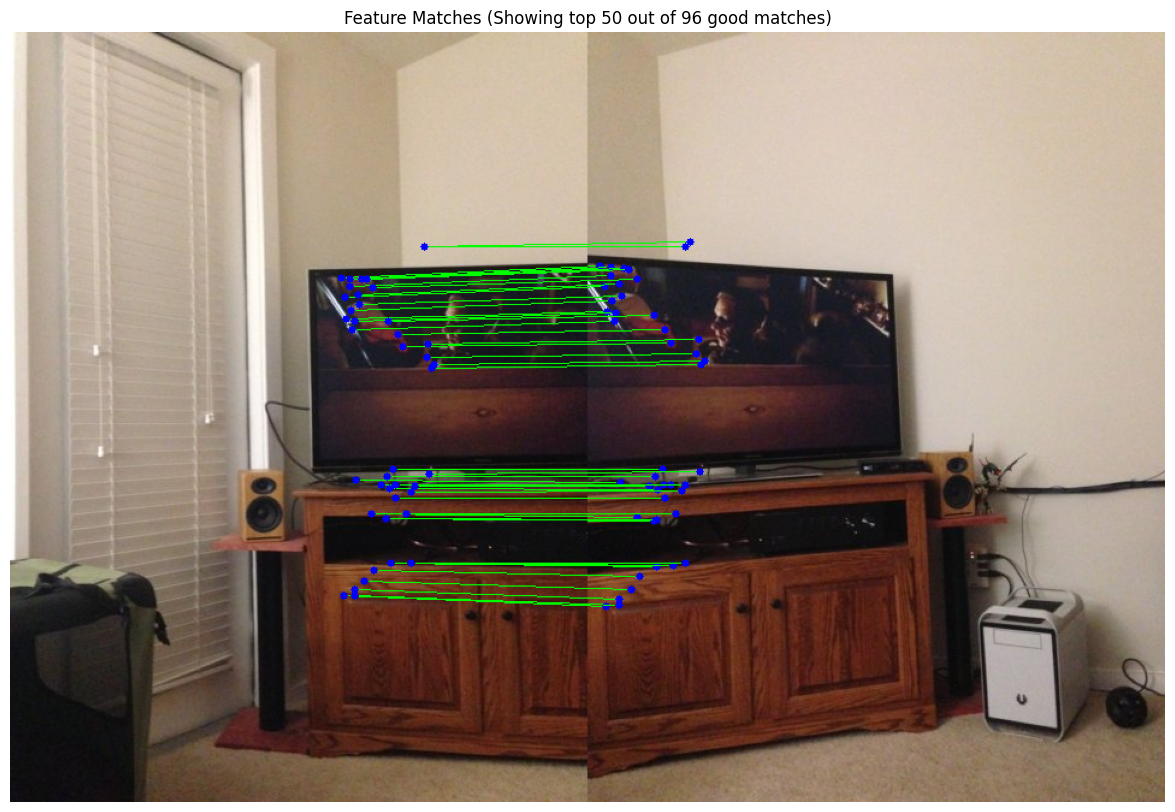

In [4]:
matchedPts1, matchedPts2 = stitcher._matchDescription(pts1, des1, pts2, des2)

h1, w1 = image1.shape[:2]
h2, w2 = image2.shape[:2]
vis = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
vis[:h1, :w1] = image1
vis[:h2, w1:w1+w2] = image2

# Draw a subset of matches to keep it readable (e.g., 50 matches)
for i in range(min(50, len(matchedPts1))):
    pt1 = (int(matchedPts1[i][0]), int(matchedPts1[i][1]))
    pt2 = (int(matchedPts2[i][0] + w1), int(matchedPts2[i][1]))
    cv2.line(vis, pt1, pt2, (0, 255, 0), 1)
    cv2.circle(vis, pt1, 3, (255, 0, 0), -1)
    cv2.circle(vis, pt2, 3, (255, 0, 0), -1)

plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"Feature Matches (Showing top 50 out of {len(matchedPts1)} good matches)")
plt.axis('off')
plt.show()

## 4. Homography and Warping
Using the matched points, we robustly estimate the homography matrix (H) with RANSAC. Then, we warp Image 1 and Image 2 into a common coordinate space.

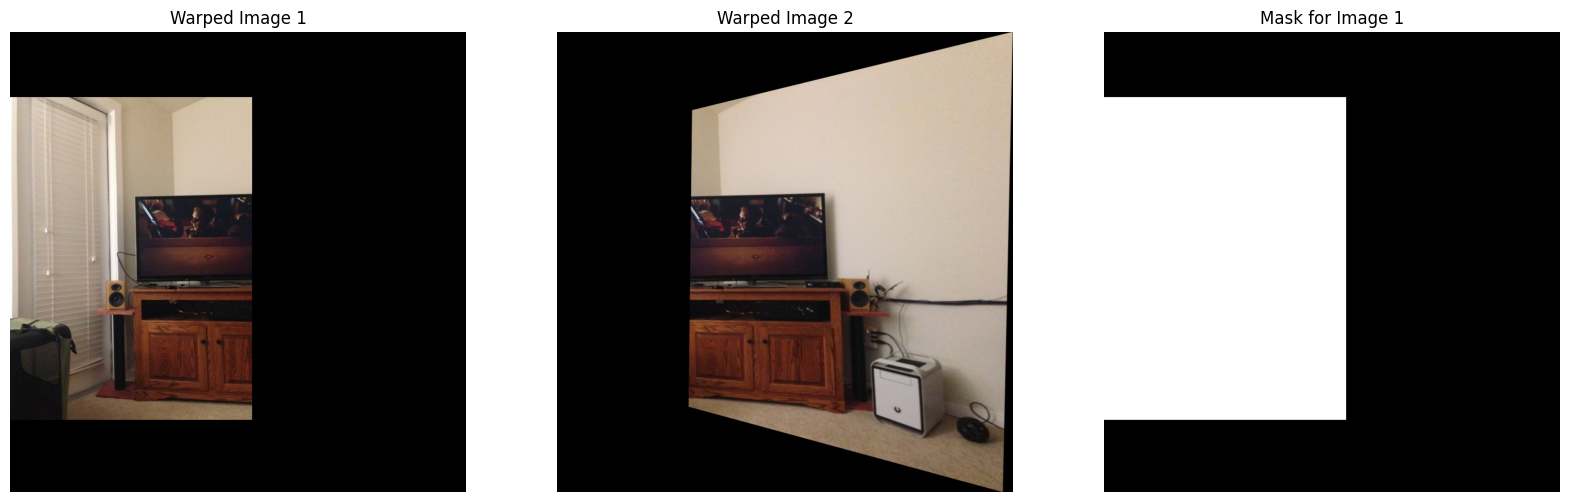

In [5]:
H = stitcher._computeHomography(matchedPts1, matchedPts2)
warpedImage1, warpedImage2, mask1 = stitcher._warp(image1, image2, H)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
ax1.imshow(cv2.cvtColor(warpedImage1.astype(np.uint8), cv2.COLOR_BGR2RGB))
ax1.set_title("Warped Image 1")
ax1.axis('off')

ax2.imshow(cv2.cvtColor(warpedImage2.astype(np.uint8), cv2.COLOR_BGR2RGB))
ax2.set_title("Warped Image 2")
ax2.axis('off')

ax3.imshow(mask1.astype(float), cmap='gray')
ax3.set_title("Mask for Image 1")
ax3.axis('off')
plt.show()

## 5. Laplacian Pyramid Blending
To reduce the seams, we build Gaussian and Laplacian pyramids and blend the images at different frequency levels.

In [6]:
imagePyramid = ImagePyramid(5)
gp1 = imagePyramid.buildGaussianPyramid(warpedImage1)
gp2 = imagePyramid.buildGaussianPyramid(warpedImage2)
gpmask = imagePyramid.buildGaussianPyramid(mask1)

lp1 = imagePyramid.buildLaplacianPyramid(gp1)
lp2 = imagePyramid.buildLaplacianPyramid(gp2)

blended_lp = []
for l1, l2, m in zip(lp1, lp2, gpmask):
    blended_lp.append(m*l1 + (1-m)*l2)

fig, axes = plt.subplots(1, len(blended_lp), figsize=(20, 4))
for i, ax in enumerate(axes):
    level_img = blended_lp[i]
    vis_img = np.clip(level_img + 128, 0, 255).astype(np.uint8)
    ax.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Blended Laplacian L{i}")
    ax.axis('off')
plt.show()

NameError: name 'np' is not defined

## 6. Final Result
Finally, we reconstruct the blended image from the blended Laplacian pyramid.

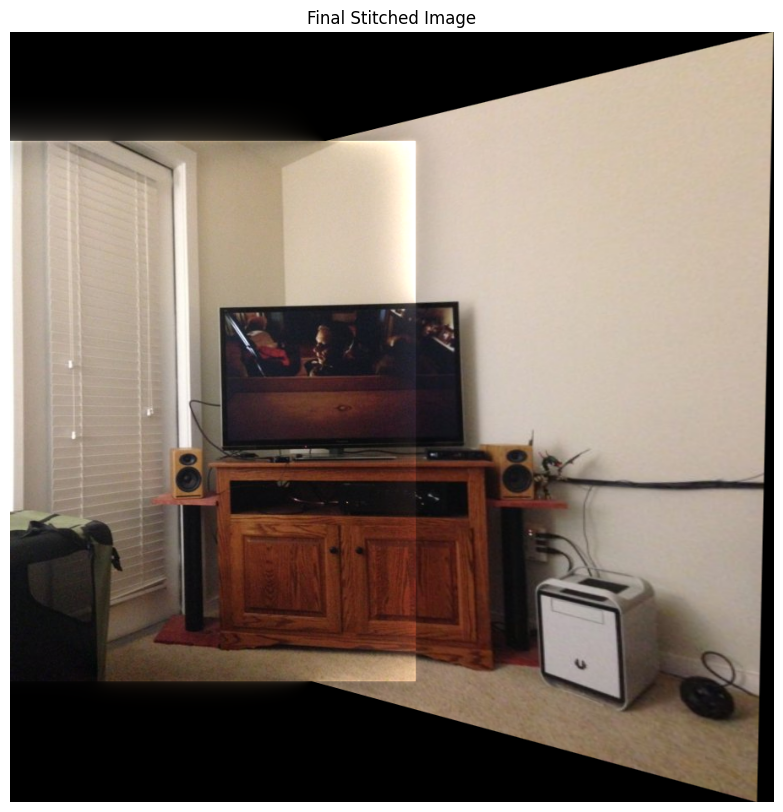

In [ ]:
stitchedImage = imagePyramid.reconstructFromLaplacianPyramid(blended_lp)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(np.clip(stitchedImage, 0, 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title("Final Stitched Image")
plt.axis('off')
plt.show()